In [1]:

from google.colab import files
import pandas as pd
uploaded = files.upload()
file_path = "EV Data.xlsx"
data = pd.ExcelFile(file_path)

Saving EV Data.xlsx to EV Data (1).xlsx


What is your maximum budget (in NTD)? 2000000
Do you have a preferred brand? (Leave blank for no preference): Any
What body style do you prefer? (Options: Sedan, SUV, Hatchback, etc.): Any
What is the minimum range (in Km) you need? 400
What is the maximum 0–100 km/h acceleration time (in seconds)? (Leave blank to ignore): 6
How many seats do you need? 5
Do you prefer a specific drivetrain? (Options: AWD, RWD, FWD, or No Preference): Any

User Input:
Budget: 2000000 NTD
Brand: Any
Body Style: Any
Min Range: 400 km
Max Acceleration Time: 6 seconds
Seats: 5
Powertrain: Any

No exact matches found based on your preferences.
Here are some recommendations focusing on budget, range, and seats:
          Brand                       Model  PriceNTD  Range_Km  AccelSec  \
1         Tesla    Model 3 Rear Wheel Drive   1899900       527       6.1   
4       Hyundai      Kona Electric (EV 450)   1550000       514       7.8   
8            MG                       ZS EV   1550000       440       8.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



Model Accuracy on Test Data: 90.48%

Machine Learning Predictions: These cars might suit your preferences:
         Brand                       Model  PriceNTD  Range_Km  AccelSec  \
1        Tesla    Model 3 Rear Wheel Drive   1899900       527       6.1   
3       Nissan            Leaf Long Range    1100000       385       6.9   
4      Hyundai      Kona Electric (EV 450)   1550000       514       7.8   
8           MG                       ZS EV   1550000       440       8.2   
13       Tesla        Model 3  Performance   1900000       568       3.1   
21     Hyundai               IONIQ 5 EV400   2000000       470       7.3   
25        Opel                     Mokka-e   1400000       406      10.0   
31      Nissan               Ariya e-4ORCE   1850000       533       7.2   
41        Ford  Mustang Mach-E Premium AWD   1600000       420       4.8   
44        Ford  Mustang Mach-E Premium RWD   1500000       480       5.2   
46         Kia                    EV6 Air    2100000    

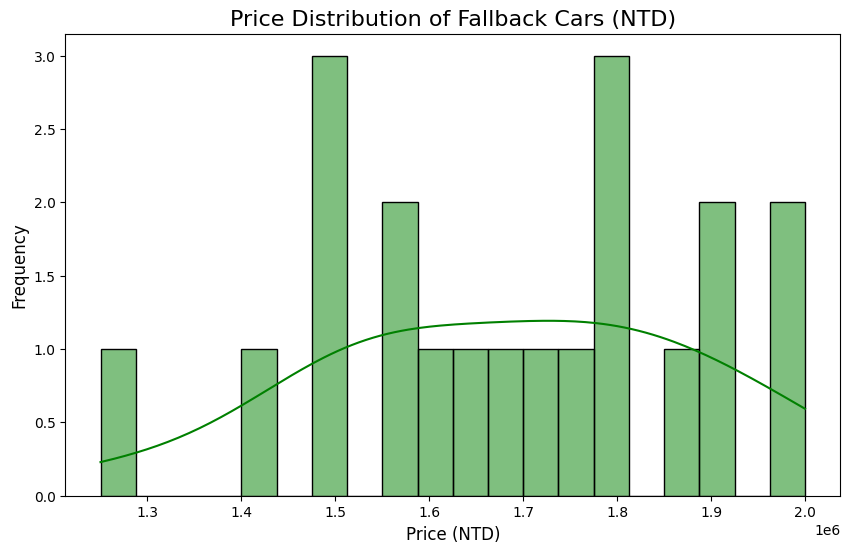

/tmp/ipykernel_1688/2455947919.py:182: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=fallback_filtered, x='BodyStyle', y='Range_Km', ci=None, palette='viridis')
/tmp/ipykernel_1688/2455947919.py:182: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fallback_filtered, x='BodyStyle', y='Range_Km', ci=None, palette='viridis')


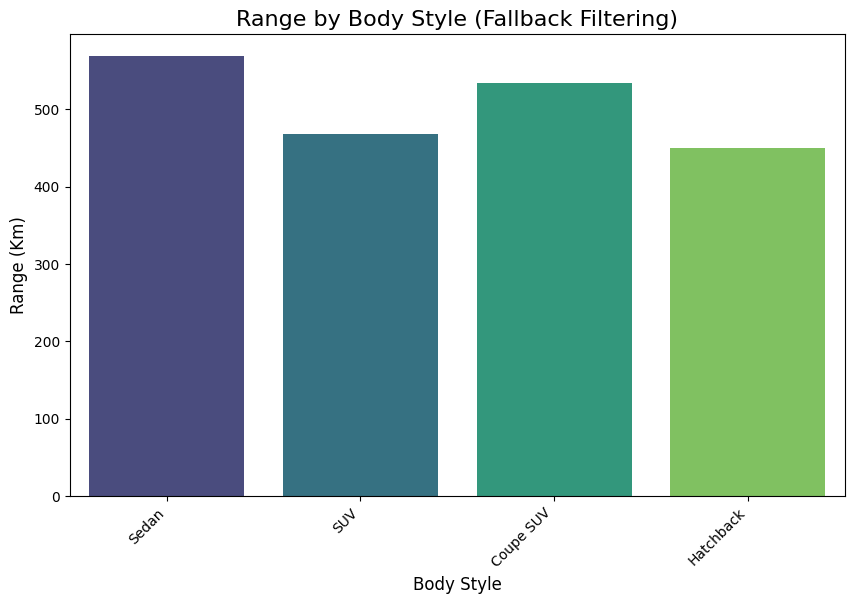

/tmp/ipykernel_1688/2455947919.py:191: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fallback_filtered, x='PowerTrain', palette='Set2')


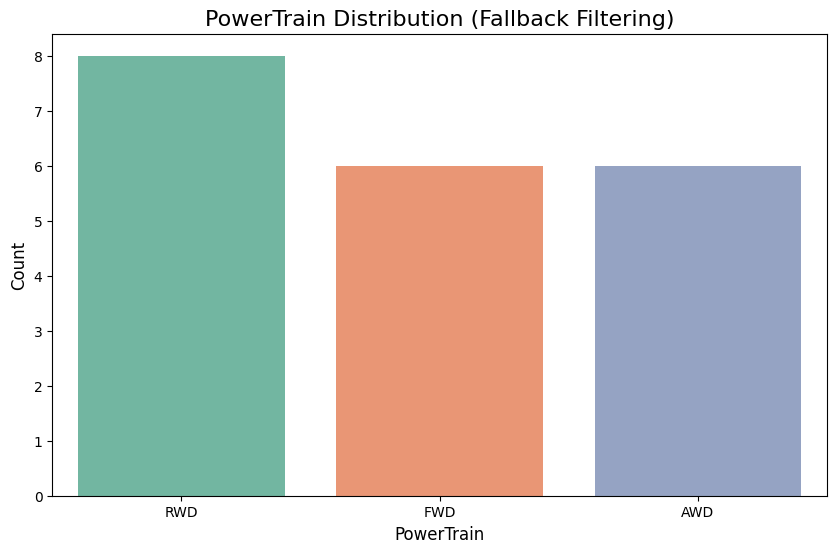

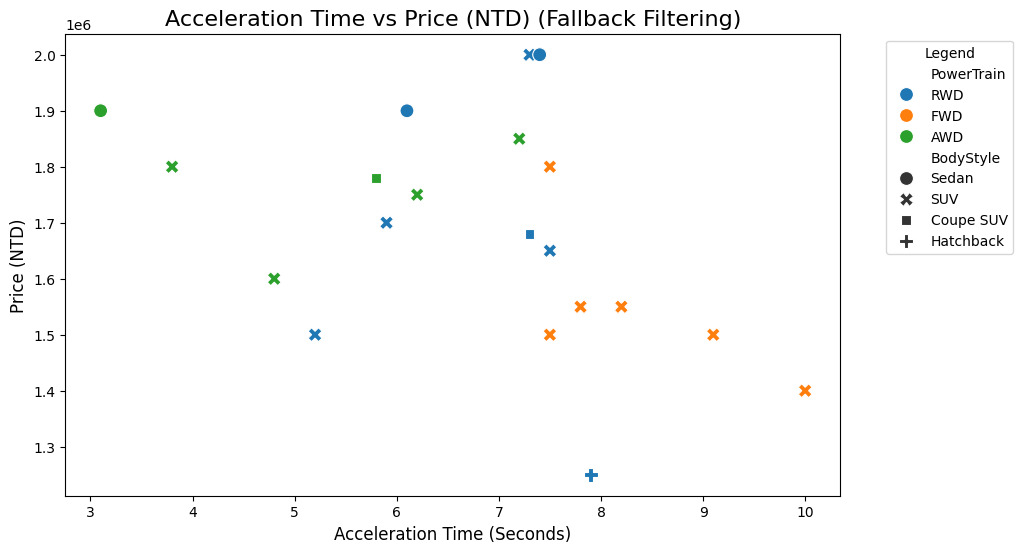


Visualizing Machine Learning Recommendations...


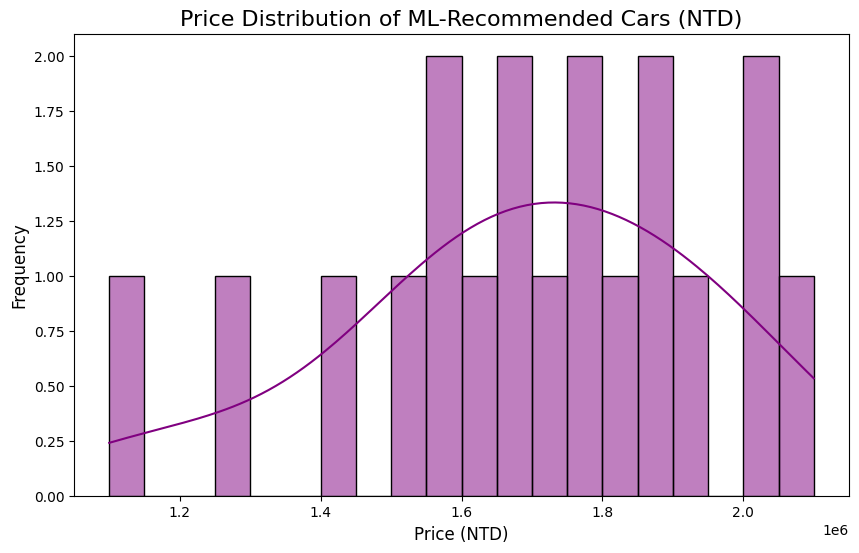

/tmp/ipykernel_1688/2455947919.py:220: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=recommended_cars, x='BodyStyle', y='Range_Km', ci=None, palette='viridis')
/tmp/ipykernel_1688/2455947919.py:220: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=recommended_cars, x='BodyStyle', y='Range_Km', ci=None, palette='viridis')


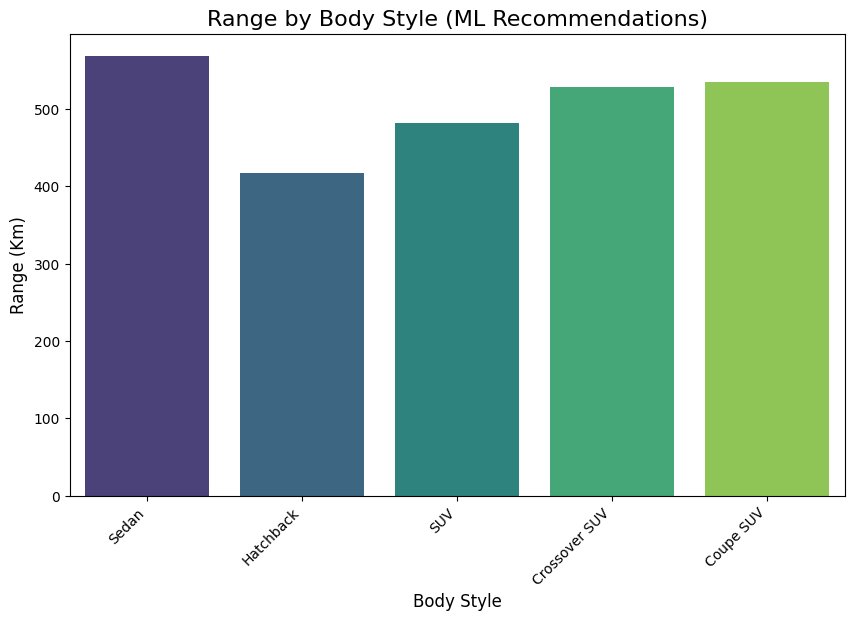

/tmp/ipykernel_1688/2455947919.py:229: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=recommended_cars, x='PowerTrain', palette='Set2')


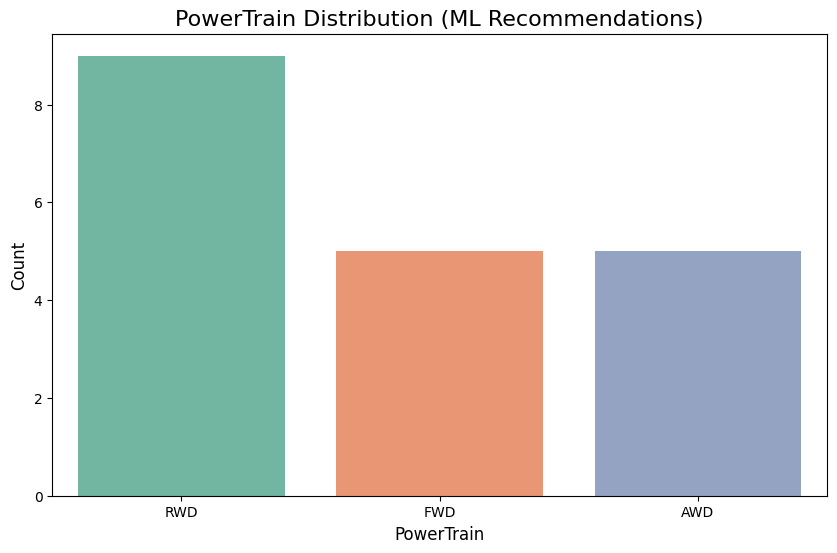

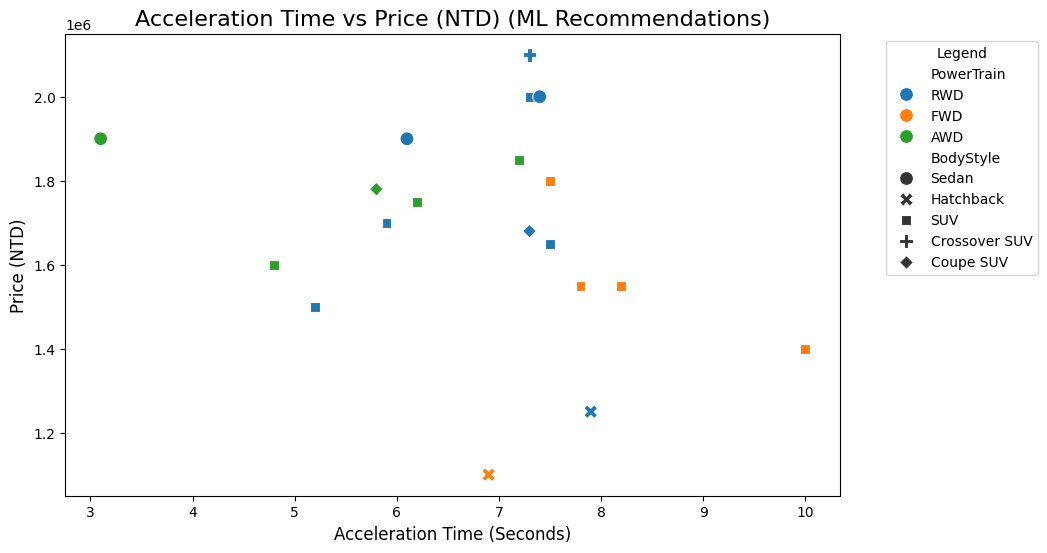

/tmp/ipykernel_1688/2455947919.py:246: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=recommended_cars, x='Model', y='Range_Km', ci=None, palette='coolwarm')
/tmp/ipykernel_1688/2455947919.py:246: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=recommended_cars, x='Model', y='Range_Km', ci=None, palette='coolwarm')


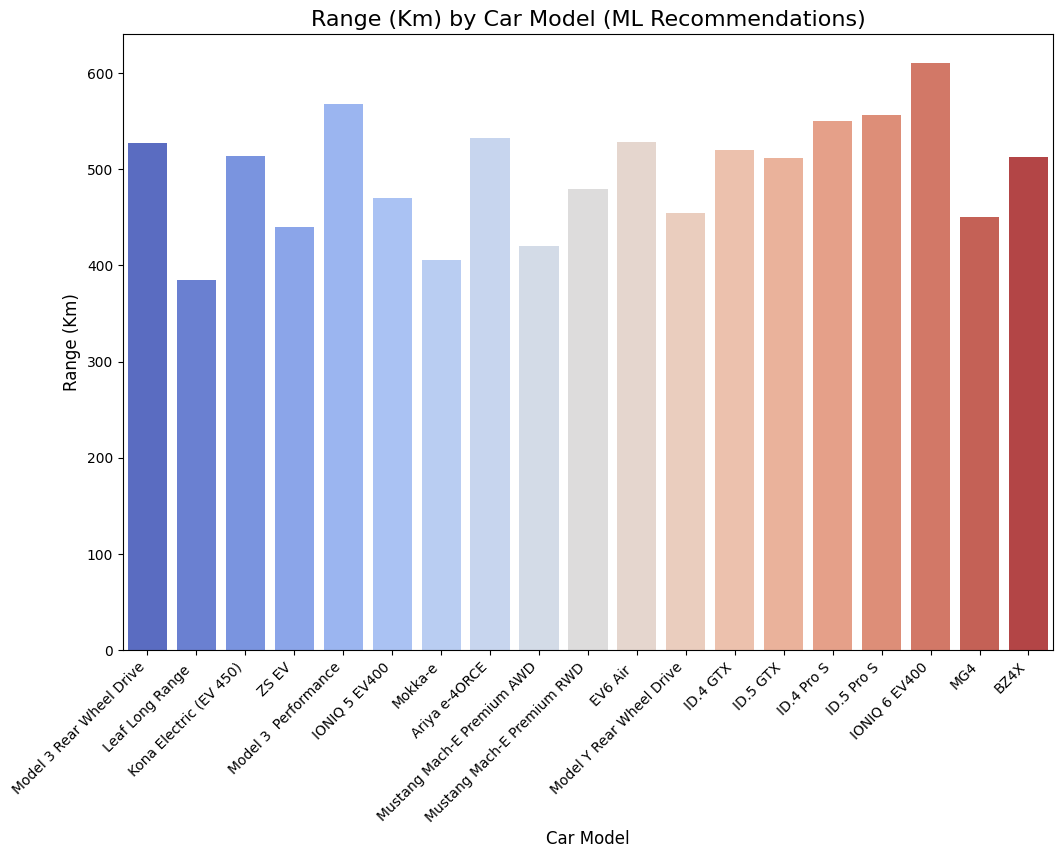

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report


df = data.parse(data.sheet_names[0], header=1)


df['PriceNTD'] = pd.to_numeric(df['PriceNTD'], errors='coerce')
df['Range_Km'] = pd.to_numeric(df['Range_Km'], errors='coerce')
df['AccelSec'] = pd.to_numeric(df['AccelSec'], errors='coerce')
df['Seats'] = pd.to_numeric(df['Seats'], errors='coerce')


budget = int(input("What is your maximum budget (in NTD)? "))
brand = input("Do you have a preferred brand? (Leave blank for no preference): ").strip()
body_style = input("What body style do you prefer? (Options: Sedan, SUV, Hatchback, etc.): ").strip()
min_range = int(input("What is the minimum range (in Km) you need? "))
max_accel = input("What is the maximum 0–100 km/h acceleration time (in seconds)? (Leave blank to ignore): ").strip()
seats = int(input("How many seats do you need? "))
powertrain = input("Do you prefer a specific drivetrain? (Options: AWD, RWD, FWD, or No Preference): ").strip()


filters = {
    'PriceNTD': budget,
    'Range_Km': min_range,
    'AccelSec': max_accel if max_accel else None,
    'Seats': seats,
    'Brand': brand if brand else None,
    'BodyStyle': body_style if body_style else None,
    'PowerTrain': powertrain if powertrain else None
}


def filter_cars(df, filters):
    filtered_df = df.copy()

    for feature, value in filters.items():
        if value:
            if feature == 'PriceNTD':
                filtered_df = filtered_df[filtered_df['PriceNTD'] <= value]
            elif feature == 'Range_Km':
                filtered_df = filtered_df[filtered_df['Range_Km'] >= value]
            elif feature == 'AccelSec' and value:
                filtered_df = filtered_df[filtered_df['AccelSec'] <= float(value)]
            elif feature == 'Seats':
                filtered_df = filtered_df[filtered_df['Seats'] == value]
            else:
                filtered_df = filtered_df[filtered_df[feature].str.contains(value, case=True, na=False)]

    return filtered_df


filtered_df = filter_cars(df, filters)


print("\n" + "="*50)
print("User Input:")
print(f"Budget: {budget} NTD")
print(f"Brand: {brand if brand else 'Any'}")
print(f"Body Style: {body_style if body_style else 'Any'}")
print(f"Min Range: {min_range} km")
print(f"Max Acceleration Time: {max_accel if max_accel else 'Any'} seconds")
print(f"Seats: {seats}")
print(f"Powertrain: {powertrain if powertrain else 'Any'}")
print("="*50)


if filtered_df.empty:
    print("\nNo exact matches found based on your preferences.")
    print("Here are some recommendations focusing on budget, range, and seats:")


    fallback_filtered = df[(df['PriceNTD'] <= budget) & (df['Range_Km'] >= min_range) & (df['Seats'] == seats)]
    print(fallback_filtered[['Brand', 'Model', 'PriceNTD', 'Range_Km', 'AccelSec', 'Seats', 'BodyStyle', 'PowerTrain']])
else:
    print("\nHere are the cars that match your exact preferences:")
    print(filtered_df[['Brand', 'Model', 'PriceNTD', 'Range_Km', 'AccelSec', 'Seats', 'BodyStyle', 'PowerTrain']])


X = df[['PriceNTD', 'Range_Km', 'Seats']]
y = (df['PriceNTD'] <= budget) & (df['Range_Km'] >= min_range) & (df['Seats'] == seats)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
model.fit(X_train_scaled, y_train)



y_test_pred = model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\nModel Accuracy on Test Data: {:.2f}%".format(test_accuracy * 100))


df['Prediction'] = model.predict(scaler.transform(df[['PriceNTD', 'Range_Km', 'Seats']]))


recommended_cars = df[df['Prediction'] == 1]

print("\n" + "="*50)
if not recommended_cars.empty:
    print("Machine Learning Predictions: These cars might suit your preferences:")
    print(recommended_cars[['Brand', 'Model', 'PriceNTD', 'Range_Km', 'AccelSec', 'Seats', 'BodyStyle', 'PowerTrain']])
else:
    print("No matches found based on the machine learning model. Please try different preferences.")
print("="*50)


print("\nModel Overall Test Accuracy: {:.2f}%".format(test_accuracy * 100))


print("\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred))



if not filtered_df.empty:
    print("\nVisualizing Strict System Recommendations...")


    plt.figure(figsize=(10, 6))
    sns.histplot(data=filtered_df, x='PriceNTD', bins=20, kde=True, color='blue')
    plt.title('Price Distribution of Strict Filtering Cars (NTD)', fontsize=16)
    plt.xlabel('Price (NTD)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.show()


    plt.figure(figsize=(10, 6))
    sns.barplot(data=filtered_df, x='BodyStyle', y='Range_Km', ci=None, palette='viridis')
    plt.title('Range by Body Style (Strict Filtering)', fontsize=16)
    plt.xlabel('Body Style', fontsize=12)
    plt.ylabel('Range (Km)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.show()


    plt.figure(figsize=(10, 6))
    sns.countplot(data=filtered_df, x='PowerTrain', palette='Set2')
    plt.title('PowerTrain Distribution (Strict Filtering)', fontsize=16)
    plt.xlabel('PowerTrain', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.show()


    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=filtered_df, x='AccelSec', y='PriceNTD', hue='PowerTrain', style='BodyStyle', s=100)
    plt.title('Acceleration Time vs Price (NTD) (Strict Filtering)', fontsize=16)
    plt.xlabel('Acceleration Time (Seconds)', fontsize=12)
    plt.ylabel('Price (NTD)', fontsize=12)
    plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()


if filtered_df.empty and not fallback_filtered.empty:
    print("\nVisualizing Fallback Recommendations...")


    plt.figure(figsize=(10, 6))
    sns.histplot(data=fallback_filtered, x='PriceNTD', bins=20, kde=True, color='green')
    plt.title('Price Distribution of Fallback Cars (NTD)', fontsize=16)
    plt.xlabel('Price (NTD)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.show()


    plt.figure(figsize=(10, 6))
    sns.barplot(data=fallback_filtered, x='BodyStyle', y='Range_Km', ci=None, palette='viridis')
    plt.title('Range by Body Style (Fallback Filtering)', fontsize=16)
    plt.xlabel('Body Style', fontsize=12)
    plt.ylabel('Range (Km)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.show()


    plt.figure(figsize=(10, 6))
    sns.countplot(data=fallback_filtered, x='PowerTrain', palette='Set2')
    plt.title('PowerTrain Distribution (Fallback Filtering)', fontsize=16)
    plt.xlabel('PowerTrain', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.show()


    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=fallback_filtered, x='AccelSec', y='PriceNTD', hue='PowerTrain', style='BodyStyle', s=100)
    plt.title('Acceleration Time vs Price (NTD) (Fallback Filtering)', fontsize=16)
    plt.xlabel('Acceleration Time (Seconds)', fontsize=12)
    plt.ylabel('Price (NTD)', fontsize=12)
    plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()


if not recommended_cars.empty:
    print("\nVisualizing Machine Learning Recommendations...")


    plt.figure(figsize=(10, 6))
    sns.histplot(data=recommended_cars, x='PriceNTD', bins=20, kde=True, color='purple')
    plt.title('Price Distribution of ML-Recommended Cars (NTD)', fontsize=16)
    plt.xlabel('Price (NTD)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.show()


    plt.figure(figsize=(10, 6))
    sns.barplot(data=recommended_cars, x='BodyStyle', y='Range_Km', ci=None, palette='viridis')
    plt.title('Range by Body Style (ML Recommendations)', fontsize=16)
    plt.xlabel('Body Style', fontsize=12)
    plt.ylabel('Range (Km)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.show()


    plt.figure(figsize=(10, 6))
    sns.countplot(data=recommended_cars, x='PowerTrain', palette='Set2')
    plt.title('PowerTrain Distribution (ML Recommendations)', fontsize=16)
    plt.xlabel('PowerTrain', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.show()


    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=recommended_cars, x='AccelSec', y='PriceNTD', hue='PowerTrain', style='BodyStyle', s=100)
    plt.title('Acceleration Time vs Price (NTD) (ML Recommendations)', fontsize=16)
    plt.xlabel('Acceleration Time (Seconds)', fontsize=12)
    plt.ylabel('Price (NTD)', fontsize=12)
    plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()


    plt.figure(figsize=(12, 8))
    sns.barplot(data=recommended_cars, x='Model', y='Range_Km', ci=None, palette='coolwarm')
    plt.title('Range (Km) by Car Model (ML Recommendations)', fontsize=16)
    plt.xlabel('Car Model', fontsize=12)
    plt.ylabel('Range (Km)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.show()